# Exploratory Data Analysis - Vietnam Land Law 2024

This notebook provides a detailed analysis of the Vietnam Land Law 2024. The analysis is divided into three sections:
1. **## 1. Raw insight**: Analysis of the original raw document (`landlaw.md`).
2. **## 2. Chunk's EDA**: Analysis of the parsed chunk files (`landlaw_chunks.json`).
3. **## 3. Evaluation set's EDA**: Analysis of the generated RAG evaluation set (`eval_landlaw_2024.json`).

## 1. Raw insight

In this section, we analyze the structure of the raw markdown document `landlaw.md`. We extract Chapters (`Chương`), Articles (`Điều`), and Clauses (`[clause]`) to map out their distributions.

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for professional charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.family'] = 'DejaVu Sans'

raw_file_path = '../data/landlaw.md'
with open(raw_file_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

chapters = []
articles = []
clauses = []
current_chapter = None
current_chapter_title = ""

for line in lines:
    line = line.strip()
    ch_match = re.match(r'^##\s+(Chương\s+[IVX]+)\.\s*(.*)$', line)
    if ch_match:
        current_chapter = ch_match.group(1).strip()
        current_chapter_title = ch_match.group(2).strip()
        chapters.append({
            'Chapter': current_chapter,
            'Title': current_chapter_title
        })
        continue
    
    art_match = re.match(r'^####\s+(Điều\s+\d+)\.\s*(.*)$', line)
    if art_match:
        if current_chapter:
            articles.append({
                'Chapter': current_chapter,
                'Article': art_match.group(1).strip(),
                'Title': art_match.group(2).strip()
            })
        continue
    
    if '[clause]' in line:
        if current_chapter:
            clauses.append({
                'Chapter': current_chapter,
                'Text': line.replace('[clause]', '').strip()
            })

df_chapters = pd.DataFrame(chapters)
df_articles = pd.DataFrame(articles)
df_clauses = pd.DataFrame(clauses)

# Group and aggregate counts
art_counts = df_articles.groupby('Chapter').size().reset_index(name='Article_Count')
cls_counts = df_clauses.groupby('Chapter').size().reset_index(name='Clause_Count')

# Merge counts
df_dist = pd.merge(df_chapters, art_counts, on='Chapter', how='left').fillna(0)
df_dist = pd.merge(df_dist, cls_counts, on='Chapter', how='left').fillna(0)
df_dist['Article_Count'] = df_dist['Article_Count'].astype(int)
df_dist['Clause_Count'] = df_dist['Clause_Count'].astype(int)
df_dist['Clauses_per_Article'] = (df_dist['Clause_Count'] / df_dist['Article_Count']).round(2)

print('Raw data successfully processed!')

Raw data successfully processed!


In [2]:
# Display compiled chapter statistics
df_dist

Chapter,Title,Article_Count,Clause_Count,Clauses_per_Article
Chương I,QUY ĐỊNH CHUNG,11,97,8.82
Chương II,"QUYỀN HẠN VÀ TRÁCH NHIỆM CỦA NHÀ NƯỚC, QUYỀN VÀ NGHĨA VỤ CỦA CÔNG DÂN ĐỐI VỚI ĐẤT ĐAI",14,76,5.43
Chương III,QUYỀN VÀ NGHĨA VỤ CỦA NGƯỜI SỬ DỤNG ĐẤT,23,84,3.65
Chương IV,"ĐỊA GIỚI ĐƠN VỊ HÀNH CHÍNH, ĐIỀU TRA CƠ BẢN VỀ ĐẤT ĐAI",11,52,4.73
Chương V,"QUY HOẠCH, KẾ HOẠCH SỬ DỤNG ĐẤT",18,91,5.06
Chương VI,"THU HỒI ĐẤT, TRƯNG DỤNG ĐẤT",13,109,8.38
Chương VII,"BỒI THƯỜNG, HỖ TRỢ, TÁI ĐỊNH CƯ KHI NHÀ NƯỚC THU HỒI ĐẤT",21,86,4.10
Chương VIII,"PHÁT TRIỂN, QUẢN LÝ VÀ KHAI THÁC QUỸ ĐẤT",4,10,2.50
Chương IX,"GIAO ĐẤT, CHO THUÊ ĐẤT, CHUYỂN MỤC ĐÍCH SỬ DỤNG ĐẤT",12,70,5.83
Chương X,"ĐĂNG KÝ ĐẤT ĐAI, CẤP GIẤY CHỨNG NHẬN QUYỀN SỬ DỤNG ĐẤT, QUYỀN SỞ HỮU TÀI SẢN GẮN LIỀN VỚI ĐẤT",25,107,4.28


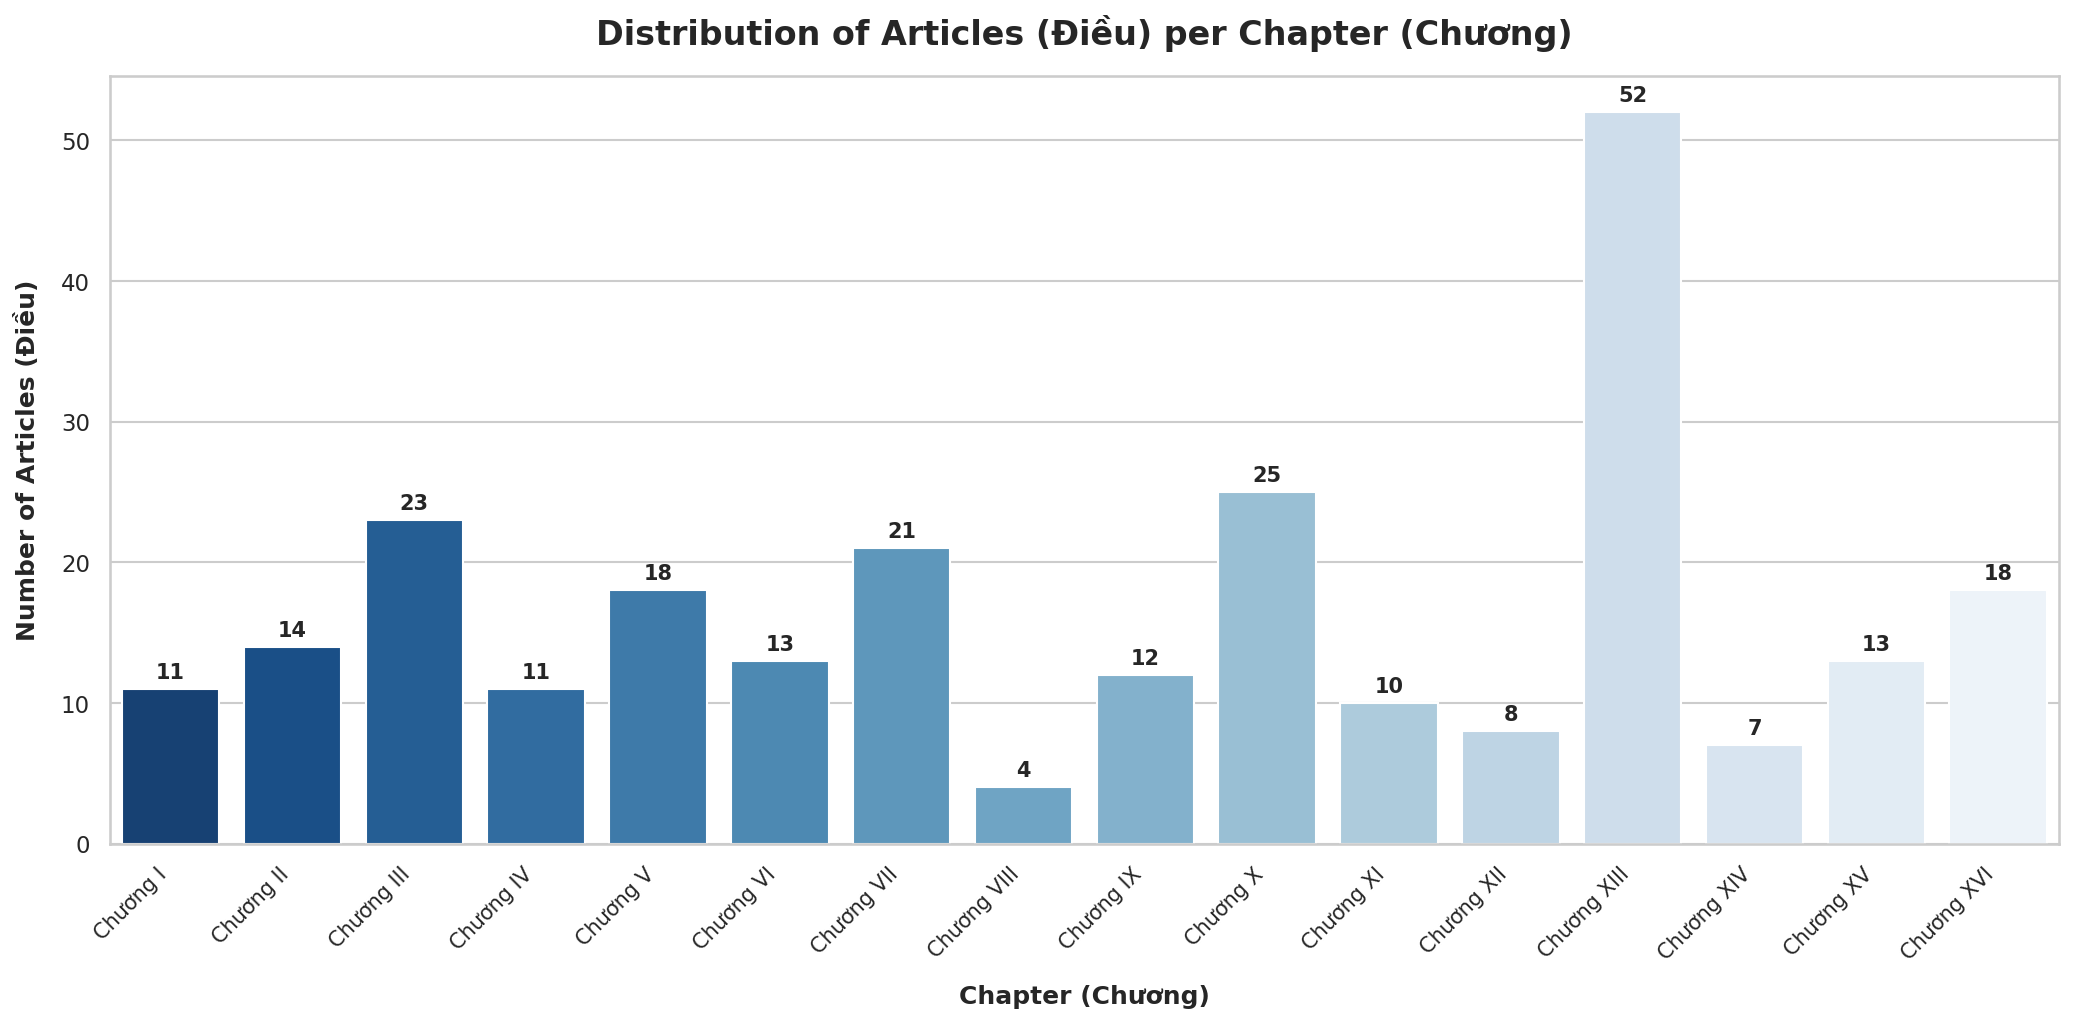

In [3]:
# Plotting Article distribution
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=df_dist, 
    x='Chapter', 
    y='Article_Count', 
    palette='Blues_r', 
    hue='Chapter',
    legend=False
)
plt.title('Distribution of Articles (#### Điều) per Chapter (## Chương)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Chapter (Chương)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Number of Articles (Điều)', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=10)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=10, fontweight='bold'
    )
plt.tight_layout()
plt.show()

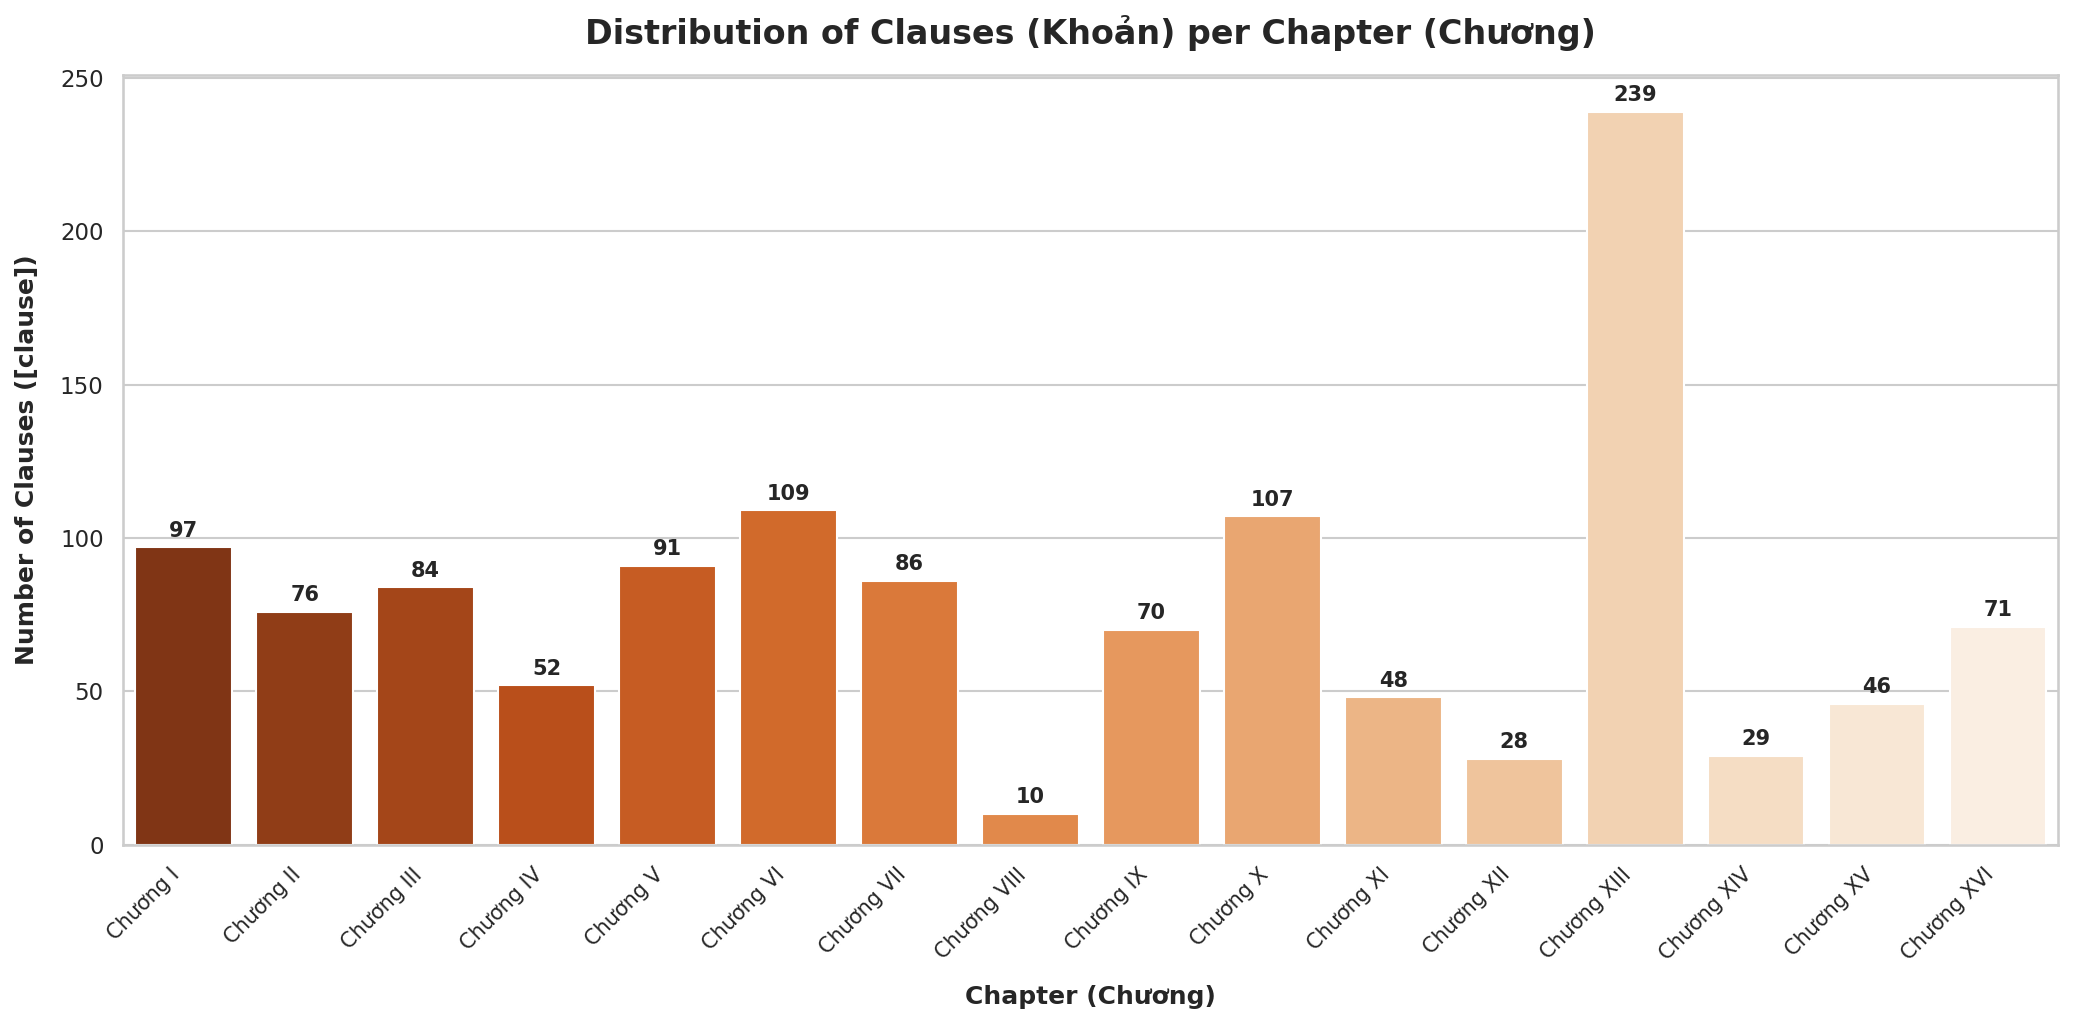

In [4]:
# Plotting Clause distribution
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=df_dist, 
    x='Chapter', 
    y='Clause_Count', 
    palette='Oranges_r', 
    hue='Chapter',
    legend=False
)
plt.title('Distribution of Clauses ([clause]) per Chapter (## Chương)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Chapter (Chương)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Number of Clauses ([clause])', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=10)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=10, fontweight='bold'
    )
plt.tight_layout()
plt.show()

## 2. Chunk's EDA

In this section, we analyze the chunks stored in `landlaw_chunks.json` which are used as documents in our RAG system. We evaluate their sizes (tokens using the Vietnamese word tokenizer `underthesea`), clause coverage, and lexical diversity. We also identify the specific chapters and articles to which the extreme chunks (minimum/maximum token and clause counts) belong.

In [5]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import underthesea

chunks_file_path = '../data/landlaw_chunks.json'
with open(chunks_file_path, 'r', encoding='utf-8') as f:
    chunks = json.load(f)

token_counts = []
clause_counts = []
ttrs = []
all_tokens = []

for chunk in chunks:
    content = chunk.get('content', '')
    metadata = chunk.get('metadata', {})
    clause_nos = metadata.get('clause_nos', [])
    
    # Word tokenize using underthesea
    tokens = underthesea.word_tokenize(content)
    num_tokens = len(tokens)
    token_counts.append(num_tokens)
    
    # Clause count
    num_clauses = len(clause_nos)
    clause_counts.append(num_clauses)
    
    # TTR
    if num_tokens > 0:
        ttr = len(set(tokens)) / num_tokens
    else:
        ttr = 0.0
    ttrs.append(ttr)
    all_tokens.extend(tokens)

avg_tokens = np.mean(token_counts)
max_tokens = np.max(token_counts)
min_tokens = np.min(token_counts)

avg_clauses = np.mean(clause_counts)
max_clauses = np.max(clause_counts)
min_clauses = np.min(clause_counts)

# Find indices for extremes
max_tok_idx = token_counts.index(max_tokens)
min_tok_idx = token_counts.index(min_tokens)
max_cls_idx = clause_counts.index(max_clauses)
min_cls_idx = clause_counts.index(min_clauses)

max_tok_meta = chunks[max_tok_idx]['metadata']
min_tok_meta = chunks[min_tok_idx]['metadata']
max_cls_meta = chunks[max_cls_idx]['metadata']
min_cls_meta = chunks[min_cls_idx]['metadata']

avg_ttr = np.mean(ttrs)
overall_ttr = len(set(all_tokens)) / len(all_tokens) if len(all_tokens) > 0 else 0.0

print('Chunks successfully processed!')

Chunks successfully processed!


In [6]:
print('--- Chunks Analysis Results ---')
print(f'Total Chunks: {len(chunks)}')
print(f'Token counts per chunk:')
print(f'  - Average: {avg_tokens:.2f}')
print(f'  - Maximum: {max_tokens}')
print(f'    * Belongs to: {max_tok_meta}')
print(f'  - Minimum: {min_tokens}')
print(f'    * Belongs to: {min_tok_meta}')
print(f'Clause counts per chunk:')
print(f'  - Average: {avg_clauses:.2f}')
print(f'  - Maximum: {max_clauses}')
print(f'    * Belongs to: {max_cls_meta}')
print(f'  - Minimum: {min_clauses}')
print(f'    * Belongs to: {min_cls_meta}')
print(f'Type Token Ratio (TTR):')
print(f'  - Average TTR per chunk: {avg_ttr:.4f}')
print(f'  - Overall Dataset TTR: {overall_ttr:.4f}')

--- Chunks Analysis Results ---
Total Chunks: 666
Token counts per chunk:
  - Average: 133.61
  - Maximum: 710
    * Belongs to: {'chapter': 'Chương X. ĐĂNG KÝ ĐẤT ĐAI, CẤP GIẤY CHỨNG NHẬN QUYỀN SỬ DỤNG ĐẤT, QUYỀN SỞ HỮU TÀI SẢN GẮN LIỀN VỚI ĐẤT', 'section': 'Mục 3. CẤP GIẤY CHỨNG NHẬN QUYỀN SỬ DỤNG ĐẤT, QUYỀN SỞ HỮU TÀI SẢN GẮN LIỀN VỚI ĐẤT', 'article': 'Điều 137. Cấp Giấy chứng nhận quyền sử dụng đất, quyền sở hữu tài sản gắn liền với đất đối với hộ gia đình, cá nhân, cộng đồng dân cư đang sử dụng đất có giấy tờ về quyền sử dụng đất', 'clause_nos': [1]}
  - Minimum: 8
    * Belongs to: {'chapter': 'Chương II. QUYỀN HẠN VÀ TRÁCH NHIỆM CỦA NHÀ NƯỚC, QUYỀN VÀ NGHĨA VỤ CỦA CÔNG DÂN ĐỐI VỚI ĐẤT ĐAI', 'section': 'Mục 1. QUYỀN HẠN VÀ TRÁCH NHIỆM CỦA NHÀ NƯỚC LÀ ĐẠI DIỆN CHỦ SỞ HỮU VỀ ĐẤT ĐAI', 'article': 'Điều 16. Trách nhiệm của Nhà nước về đất đai đối với đồng bào dân tộc thiểu số', 'clause_nos': [9]}
Clause counts per chunk:
  - Average: 1.87
  - Maximum: 11
    * Belongs to: {'chapter':

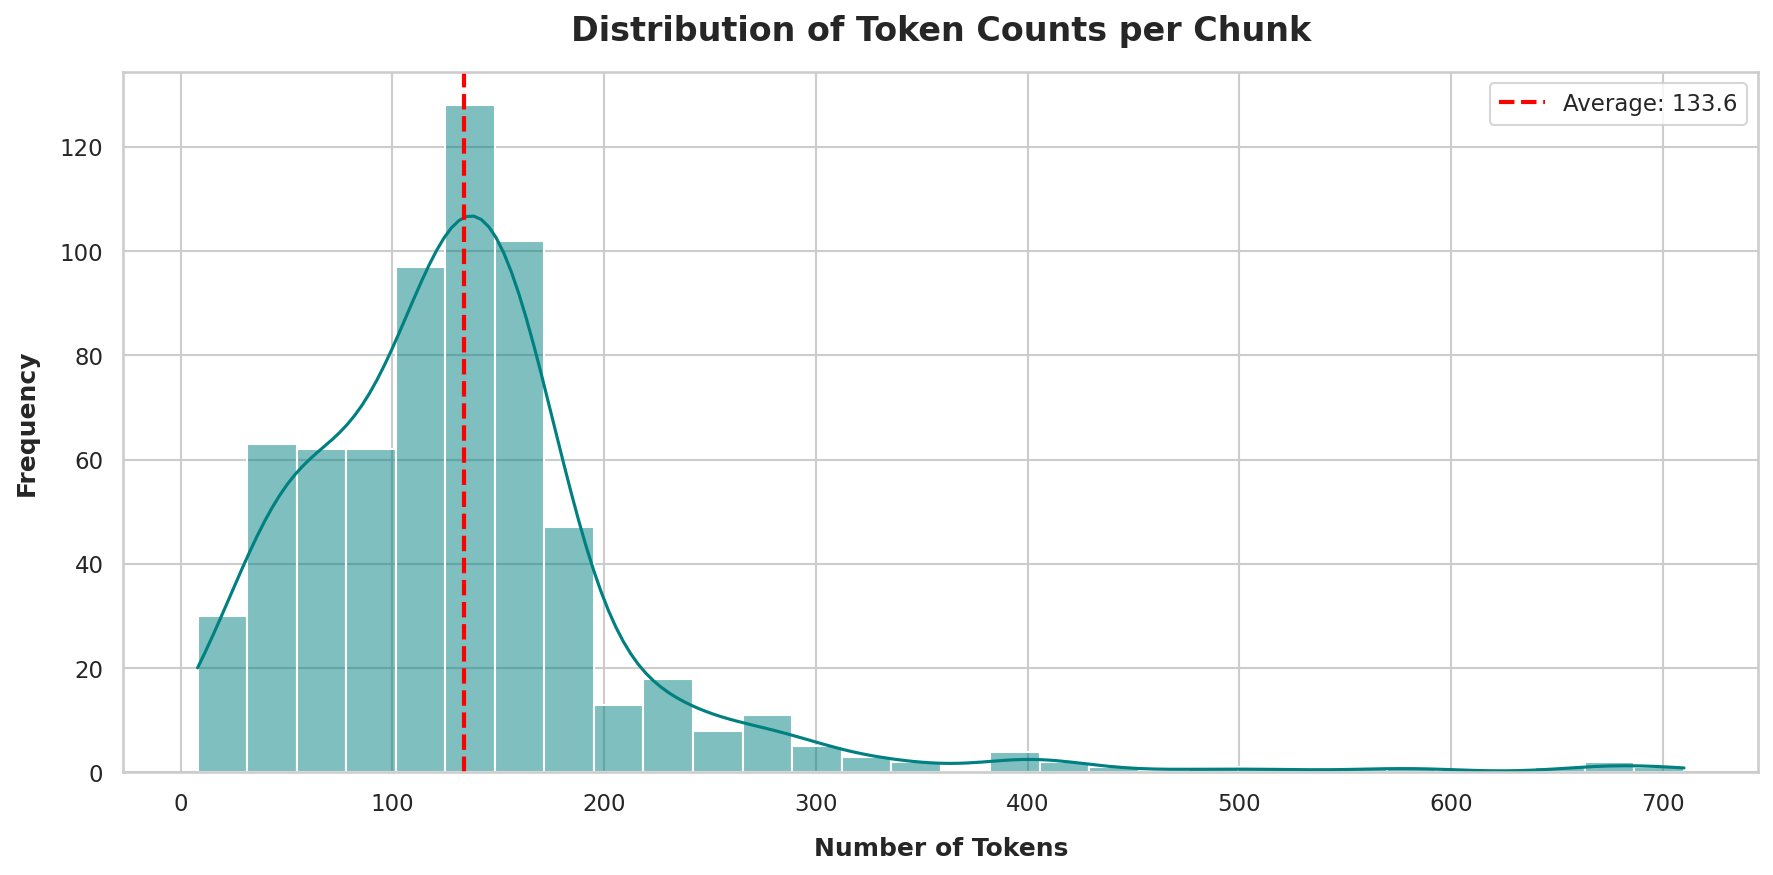

In [7]:
# Plotting Token Count Distribution
plt.figure(figsize=(12, 6))
sns.histplot(token_counts, bins=30, kde=True, color='teal')
plt.title('Distribution of Token Counts per Chunk', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Tokens', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Frequency', fontsize=12, fontweight='bold', labelpad=10)
plt.axvline(avg_tokens, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_tokens:.1f}')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

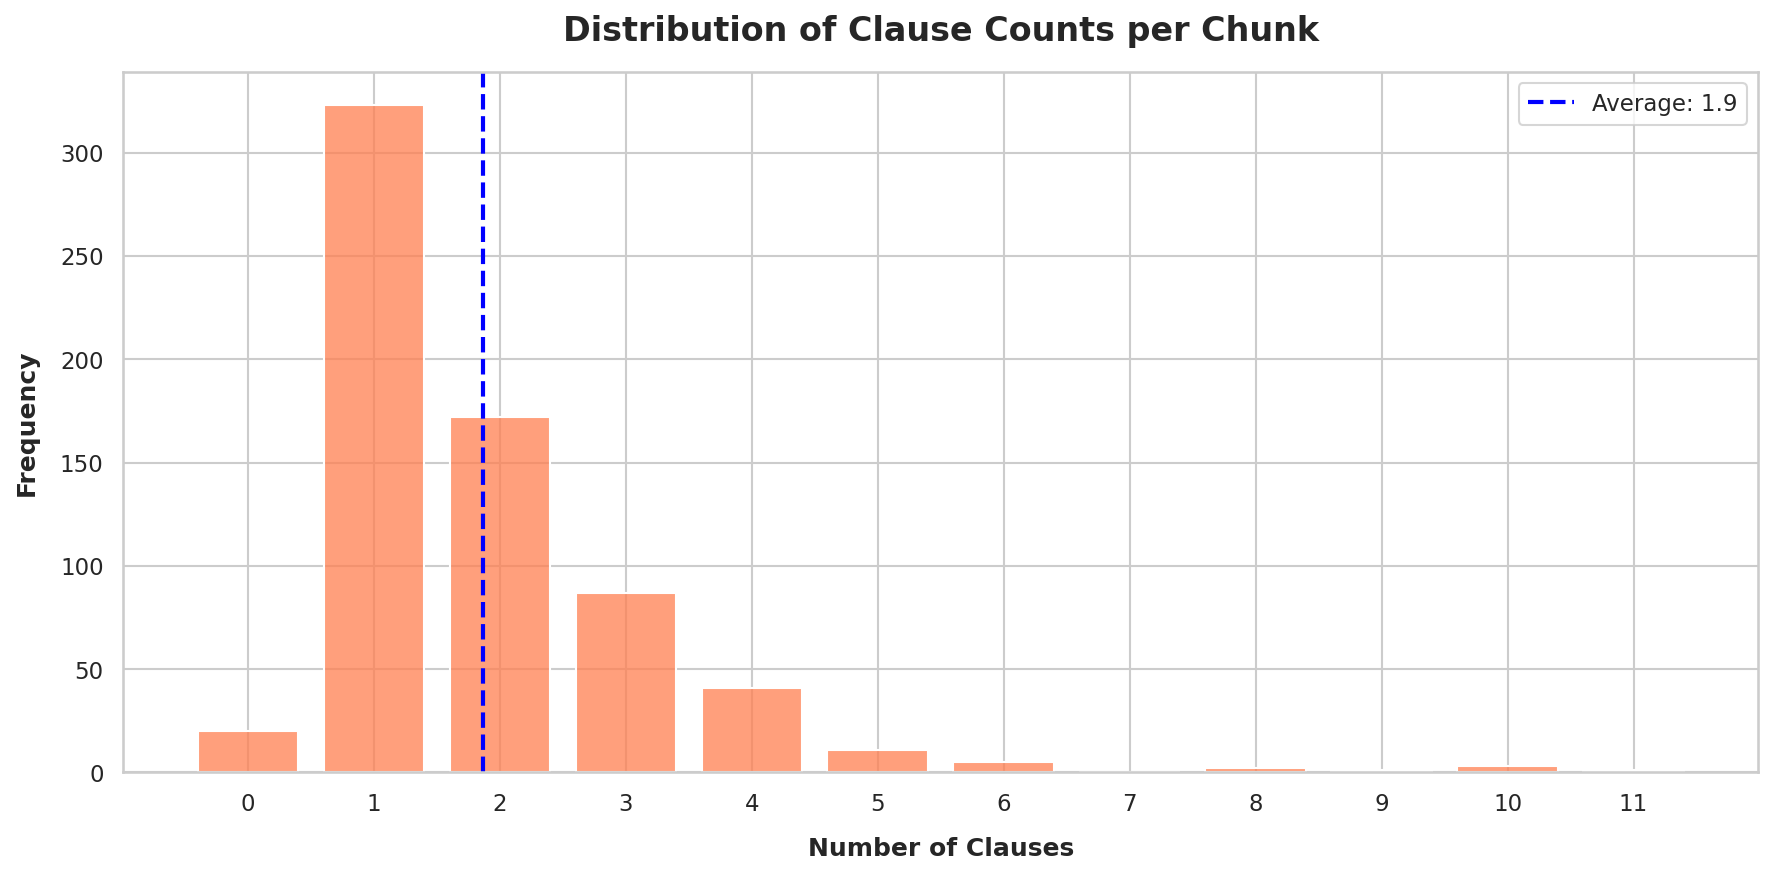

In [8]:
# Plotting Clause Count Distribution
plt.figure(figsize=(12, 6))
sns.histplot(clause_counts, discrete=True, color='coral', shrink=0.8)
plt.title('Distribution of Clause Counts per Chunk', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Clauses', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Frequency', fontsize=12, fontweight='bold', labelpad=10)
plt.axvline(avg_clauses, color='blue', linestyle='--', linewidth=2, label=f'Average: {avg_clauses:.1f}')
plt.legend(fontsize=11)
plt.xticks(range(int(max_clauses) + 1))
plt.tight_layout()
plt.show()

## 3. Evaluation set's EDA

In this section, we analyze the RAG evaluation dataset `eval_landlaw_2024.json`. We evaluate the distribution of each `question_type`, compile statistics on vocabulary diversity (TTR) comparing questions and answers, and compile average token lengths for questions and their corresponding answers across different query types.

In [9]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import underthesea

eval_file_path = '../data/eval_landlaw_2024.json'
with open(eval_file_path, 'r', encoding='utf-8') as f:
    eval_set = json.load(f)

eval_data = eval_set['data']
eval_records = []

for q in eval_data:
    q_text = q['question']
    a_text = q['answer']
    q_type = q['question_type']
    
    q_toks = underthesea.word_tokenize(q_text)
    a_toks = underthesea.word_tokenize(a_text)
    
    q_len = len(q_toks)
    a_len = len(a_toks)
    
    q_ttr = len(set(q_toks)) / q_len if q_len > 0 else 0.0
    a_ttr = len(set(a_toks)) / a_len if a_len > 0 else 0.0
    
    eval_records.append({
        'id': q['id'],
        'question_type': q_type,
        'q_len': q_len,
        'a_len': a_len,
        'q_ttr': q_ttr,
        'a_ttr': a_ttr
    })

df_eval = pd.DataFrame(eval_records)
type_counts = df_eval['question_type'].value_counts().reset_index()
type_counts.columns = ['Question_Type', 'Count']

df_eval_agg = df_eval.groupby('question_type')[['q_len', 'a_len']].mean().reset_index()
df_eval_agg.columns = ['Question_Type', 'Avg_Question_Tokens', 'Avg_Answer_Tokens']
df_eval_agg['Avg_Question_Tokens'] = df_eval_agg['Avg_Question_Tokens'].round(2)
df_eval_agg['Avg_Answer_Tokens'] = df_eval_agg['Avg_Answer_Tokens'].round(2)

print('Evaluation data processed successfully!')

Evaluation data processed successfully!


In [10]:
# Display the distribution of question types
type_counts

Question_Type,Count
factual,30
yes_no,22
listing,20
conditional,14
situational,13
definition,10
multi_hop,5


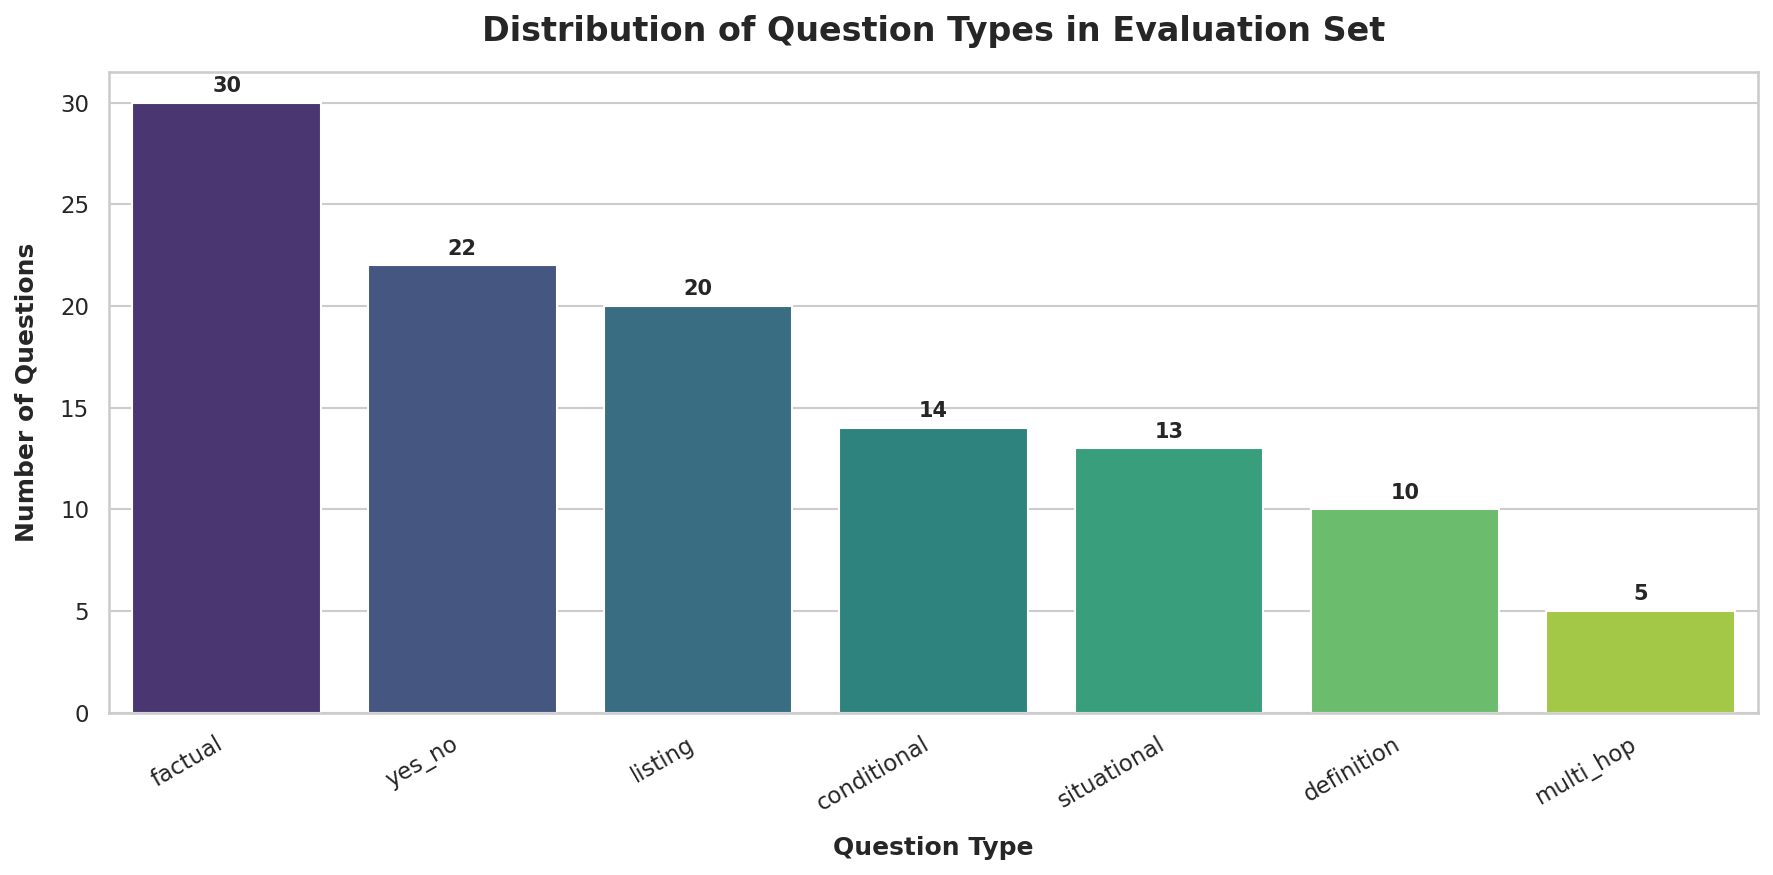

In [11]:
# Plotting Question Type Distribution
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=type_counts, 
    x='Question_Type', 
    y='Count', 
    palette='viridis', 
    hue='Question_Type',
    legend=False
)
plt.title('Distribution of Question Types in Evaluation Set', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Question Type', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Number of Questions', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation=30, ha='right')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=10, fontweight='bold'
    )
plt.tight_layout()
plt.show()

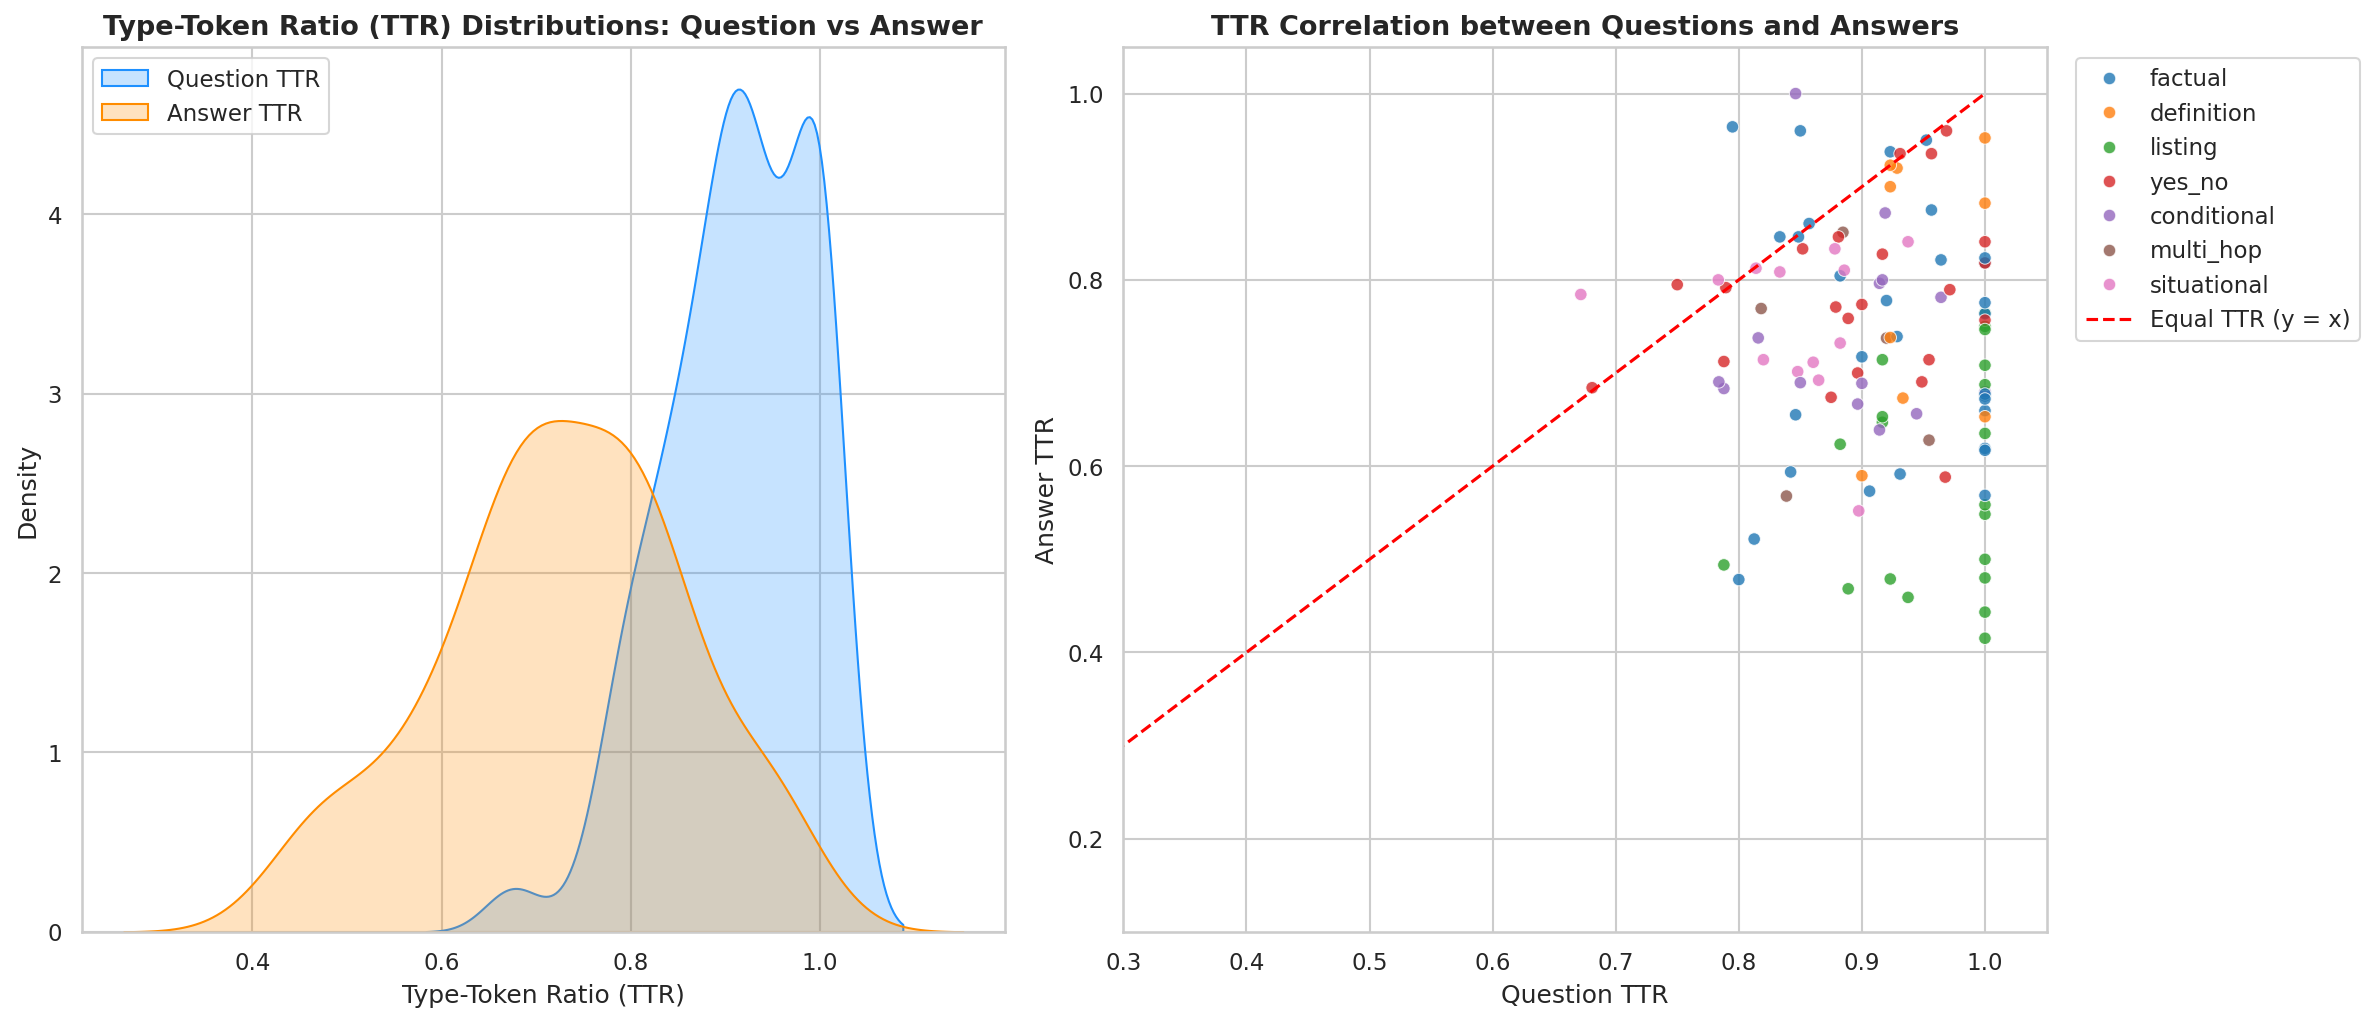

In [12]:
# Plotting TTR comparison between questions and answers
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# KDE distributions
sns.kdeplot(data=df_eval, x='q_ttr', fill=True, color='dodgerblue', label='Question TTR', ax=axes[0])
sns.kdeplot(data=df_eval, x='a_ttr', fill=True, color='darkorange', label='Answer TTR', ax=axes[0])
axes[0].set_title('Type-Token Ratio (TTR) Distributions: Question vs Answer', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Type-Token Ratio (TTR)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Scatter correlation
sns.scatterplot(data=df_eval, x='q_ttr', y='a_ttr', hue='question_type', palette='tab10', ax=axes[1], alpha=0.8)
axes[1].plot([0.1, 1], [0.1, 1], color='red', linestyle='--', label='Equal TTR (y = x)')
axes[1].set_title('TTR Correlation between Questions and Answers', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Question TTR')
axes[1].set_ylabel('Answer TTR')
axes[1].set_xlim(0.3, 1.05)
axes[1].set_ylim(0.1, 1.05)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [13]:
# Display compiled average token count dataframe per question type
df_eval_agg

Question_Type,Avg_Question_Tokens,Avg_Answer_Tokens
conditional,28.71,51.64
definition,13.20,31.30
factual,21.87,44.13
listing,14.05,82.85
multi_hop,27.40,69.20
situational,43.77,59.62
yes_no,29.09,44.36


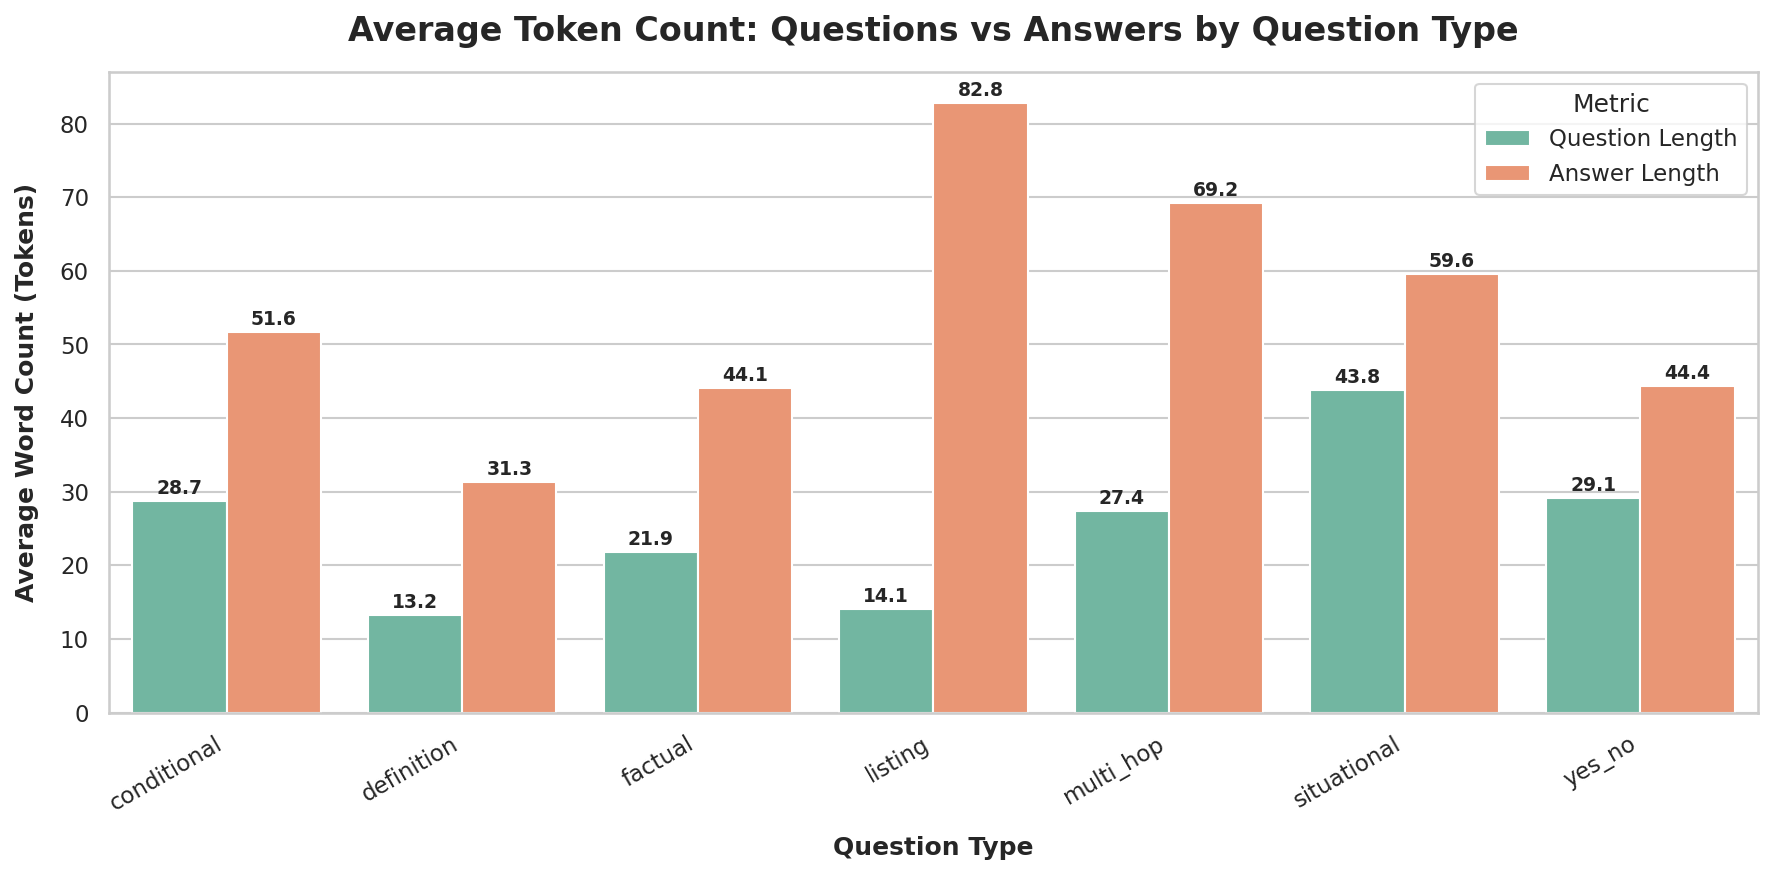

In [14]:
# Melt for plotting
df_melted_eval = df_eval_agg.melt(id_vars='Question_Type', value_vars=['Avg_Question_Tokens', 'Avg_Answer_Tokens'],
                                 var_name='Metric', value_name='Avg_Tokens')
df_melted_eval['Metric'] = df_melted_eval['Metric'].map({'Avg_Question_Tokens': 'Question Length', 'Avg_Answer_Tokens': 'Answer Length'})

# Plotting grouped bar chart of token counts
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_melted_eval, x='Question_Type', y='Avg_Tokens', hue='Metric', palette='Set2')
plt.title('Average Token Count: Questions vs Answers by Question Type', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Question Type', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Average Word Count (Tokens)', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation=30, ha='right')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f'{p.get_height():.1f}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center',
            xytext=(0, 6),
            textcoords='offset points',
            fontsize=9, fontweight='bold'
        )
plt.tight_layout()
plt.show()

### Key Observations on the Evaluation Dataset:

1. **Question Type Distribution**:
   - The evaluation dataset consists of **114 QA pairs**.
   - **Factual questions** are the most represented (**30 questions**, 26.3%), followed by **Yes/No questions** (**22 questions**, 19.3%) and **Listing questions** (**20 questions**, 17.5%). This is representative of general RAG testing setups, where direct facts and simple validations constitute the bulk of user queries.
   - Complex query types like **conditional** (14), **situational** (13), and **definition** (10) are also well represented, with **multi-hop** questions being the smallest group (**5 questions**, 4.4%), which is expected due to their difficulty.

2. **Type-Token Ratio (TTR) Contrast**:
   - Questions consistently exhibit a much higher TTR than answers (distribution shifted close to **0.8 - 0.9** for questions, compared to **0.4 - 0.6** for answers). 
   - This indicates that questions are short and concise, with very few repeated words. Answers, on the other hand, are longer and draw from legal references, which naturally repeat terms (e.g. "đất", "sử dụng", "quy định") resulting in lower TTR.

3. **Token Length Characteristics**:
   - **Answers are consistently longer than their corresponding questions** across all question types.
   - **Listing answers** have the highest average length (**82.85 tokens**), which is logical as listing out legal conditions or categories requires a larger volume of text.
   - **Situational questions** are the longest query types (**43.77 tokens**) because they need to present detailed mock scenarios, conditions, and background context before asking a question.
   - **Definition questions** are the shortest query types (**13.20 tokens**) and have the shortest answers (**31.30 tokens**) because legal definitions in Land Law 2024 are typically direct and concise (e.g., definitions from Điều 3).